In [107]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Getting Data

In [108]:
raw_data = pd.read_csv(r"C:\Users\micha\Downloads\nfl_data\play_by_play_2010.csv")
for yr in range(2011, 2021):
    raw_data = pd.concat([raw_data, pd.read_csv(r"C:\Users\micha\Downloads\nfl_data\play_by_play_" + str(yr) + ".csv")]).reset_index(drop=True)

In [109]:
df_temp = raw_data.copy()
df_temp['Season'] = df_temp['game_id'].apply(lambda x:x[:4])

In [110]:
off_ranks = []
def_ranks = []

for season in sorted(df_temp['Season'].unique()):
    games = 16 if int(season) < 2021 else 17  # NFL moved to 17 games in 2021

    off = (
        df_temp.loc[(df_temp['Season'] == season) & (df_temp['season_type'] == 'REG'), ['posteam', 'yards_gained']]
        .groupby('posteam').sum().div(games)
        .rename(columns={'yards_gained': 'off_yards_per_game'})
    )
    off['off_rank'] = off['off_yards_per_game'].rank(method='min', ascending=False).astype(int)
    off['Season'] = season
    off_ranks.append(off.reset_index())

    def_ = (
        df_temp.loc[(df_temp['Season'] == season) & (df_temp['season_type'] == 'REG'), ['defteam', 'yards_gained']]
        .groupby('defteam').sum().div(games)
        .rename(columns={'yards_gained': 'def_yards_per_game'})
    )
    def_['def_rank'] = def_['def_yards_per_game'].rank(method='min', ascending=True).astype(int)
    def_['Season'] = season
    def_ranks.append(def_.reset_index())

off_ranks = pd.concat(off_ranks).rename(columns={'posteam': 'team'})
def_ranks = pd.concat(def_ranks).rename(columns={'defteam': 'team'})

df_temp = df_temp.merge(
    off_ranks[['Season', 'team', 'off_yards_per_game', 'off_rank']],
    left_on=['Season', 'posteam'], right_on=['Season', 'team'], how='left'
).drop(columns='team')

df_temp = df_temp.merge(
    def_ranks[['Season', 'team', 'def_yards_per_game', 'def_rank']],
    left_on=['Season', 'defteam'], right_on=['Season', 'team'], how='left'
).drop(columns='team')

df_temp.head()

,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe,Season,off_yards_per_game,off_rank,def_yards_per_game,def_rank
0,1,2010_01_ARI_STL,2010091208,LA,ARI,REG,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2010,NaN,NaN,NaN,NaN
1,36,2010_01_ARI_STL,2010091208,LA,ARI,REG,1,ARI,away,LA,...,NaN,NaN,NaN,NaN,NaN,2010,268.8125,31.0,336.875,19.0
2,58,2010_01_ARI_STL,2010091208,LA,ARI,REG,1,ARI,away,LA,...,6.0,0.690780,0.224250,0.502033,49.796659,2010,268.8125,31.0,336.875,19.0
3,82,2010_01_ARI_STL,2010091208,LA,ARI,REG,1,ARI,away,LA,...,NaN,NaN,NaN,0.499817,-49.981695,2010,268.8125,31.0,336.875,19.0
4,103,2010_01_ARI_STL,2010091208,LA,ARI,REG,1,ARI,away,LA,...,1.0,0.998045,0.998045,0.962868,3.713167,2010,268.8125,31.0,336.875,19.0


In [121]:
name_to_abbr = {
    'Atlanta Falcons': 'ATL',
    'Arizona Cardinals': 'ARI',
    'Baltimore Ravens': 'BAL',
    'Buffalo Bills': 'BUF',
    'Carolina Panthers': 'CAR',
    'Chicago Bears': 'CHI',
    'Cincinnati Bengals': 'CIN',
    'Cleveland Browns': 'CLE',
    'Dallas Cowboys': 'DAL',
    'Denver Broncos': 'DEN',
    'Detroit Lions': 'DET',
    'Green Bay Packers': 'GB',
    'Houston Texans': 'HOU',
    'Indianapolis Colts': 'IND',
    'Jacksonville Jaguars': 'JAX',
    'Kansas City Chiefs': 'KC',
    'St. Louis Rams': 'LA',
    'San Diego Chargers': 'LAC',
    'Oakland Raiders': 'LV',
    'Miami Dolphins': 'MIA',
    'Minnesota Vikings': 'MIN',
    'New England Patriots': 'NE',
    'New Orleans Saints': 'NO',
    'New York Giants': 'NYG',
    'New York Jets': 'NYJ',
    'Philadelphia Eagles': 'PHI',
    'Pittsburgh Steelers': 'PIT',
    'Seattle Seahawks': 'SEA',
    'San Francisco 49ers': 'SF',
    'Tampa Bay Buccaneers': 'TB',
    'Tennessee Titans': 'TEN',
    'Washington Redskins': 'WAS',
}

# ── Load Excel data for 2007, 2008, 2009 ──────────────────────────────────────
def load_external_year(year):
    off = pd.read_excel(f'{year} ranks.xlsx', sheet_name='offense')
    def_ = pd.read_excel(f'{year} ranks.xlsx', sheet_name='defense')
    off['team'] = off['Team'].map(name_to_abbr)
    def_['team'] = def_['Team'].map(name_to_abbr)
    off = off.set_index('team')[['YDS/G']].rename(columns={'YDS/G': 'off_ypg'})
    def_ = def_.set_index('team')[['YDS/G allowed']].rename(columns={'YDS/G allowed': 'def_ypg'})
    return off, def_

ext_off = {}; ext_def = {}
for yr in [2007, 2008, 2009]:
    ext_off[yr], ext_def[yr] = load_external_year(yr)

# ── Helper: get per-team YPG for a season from df_temp ───────────────────────
def get_ypg_from_df(season_str):
    s = df_temp.loc[(df_temp['Season'] == season_str) & (df_temp['season_type'] == 'REG')]
    off = s.groupby('posteam')['yards_gained'].sum().div(16).rename('off_ypg')
    def_ = s.groupby('defteam')['yards_gained'].sum().div(16).rename('def_ypg')
    return off.to_frame(), def_.to_frame()

# ── Helper: average YPG across a list of (off_df, def_df) tuples ─────────────
def avg_ypg(frames_off, frames_def):
    off_avg = pd.concat(frames_off).groupby(level=0)['off_ypg'].mean().to_frame()
    def_avg = pd.concat(frames_def).groupby(level=0)['def_ypg'].mean().to_frame()
    return off_avg, def_avg

# ── Apply 2009 lagged data → 2010 season (1-year lag) ────────────────────────
prev_off_2009 = pd.read_excel('2009 ranks.xlsx', sheet_name='offense')
prev_def_2009 = pd.read_excel('2009 ranks.xlsx', sheet_name='defense')
prev_off_2009['team'] = prev_off_2009['Team'].map(name_to_abbr)
prev_def_2009['team'] = prev_def_2009['Team'].map(name_to_abbr)
prev_off_2009 = prev_off_2009.rename(columns={'Rank': 'prev_off_rank', 'YDS/G': 'prev_off_ypg'}).set_index('team')[['prev_off_ypg', 'prev_off_rank']]
prev_def_2009 = prev_def_2009.rename(columns={'Rank': 'prev_def_rank', 'YDS/G allowed': 'prev_def_ypg'}).set_index('team')[['prev_def_ypg', 'prev_def_rank']]

mask_2010 = df_temp['Season'] == '2010'
df_temp.loc[mask_2010, 'prev_off_ypg']  = df_temp.loc[mask_2010, 'posteam'].map(prev_off_2009['prev_off_ypg'])
df_temp.loc[mask_2010, 'prev_off_rank'] = df_temp.loc[mask_2010, 'posteam'].map(prev_off_2009['prev_off_rank'])
df_temp.loc[mask_2010, 'prev_def_ypg']  = df_temp.loc[mask_2010, 'defteam'].map(prev_def_2009['prev_def_ypg'])
df_temp.loc[mask_2010, 'prev_def_rank'] = df_temp.loc[mask_2010, 'defteam'].map(prev_def_2009['prev_def_rank'])

# ── Apply 3-year lagged data → 2010 season (avg of 2007, 2008, 2009) ─────────
off_3yr, def_3yr = avg_ypg(
    [ext_off[2007], ext_off[2008], ext_off[2009]],
    [ext_def[2007], ext_def[2008], ext_def[2009]]
)
off_3yr['off_3yr_rank'] = off_3yr['off_ypg'].rank(method='min', ascending=False).astype(int)
def_3yr['def_3yr_rank'] = def_3yr['def_ypg'].rank(method='min', ascending=True).astype(int)

df_temp.loc[mask_2010, 'prev_off_3yr_ypg']  = df_temp.loc[mask_2010, 'posteam'].map(off_3yr['off_ypg'])
df_temp.loc[mask_2010, 'prev_off_3yr_rank'] = df_temp.loc[mask_2010, 'posteam'].map(off_3yr['off_3yr_rank'])
df_temp.loc[mask_2010, 'prev_def_3yr_ypg']  = df_temp.loc[mask_2010, 'defteam'].map(def_3yr['def_ypg'])
df_temp.loc[mask_2010, 'prev_def_3yr_rank'] = df_temp.loc[mask_2010, 'defteam'].map(def_3yr['def_3yr_rank'])

# ── Loop over all subsequent seasons ─────────────────────────────────────────
for season in sorted(df_temp['Season'].unique()):
    season = str(season)
    prev_season = str(int(season) - 1)
    if prev_season == '2009':
        continue  # already handled above

    # ── 1-year lag (from df_temp) ──
    off_lag, def_lag = get_ypg_from_df(prev_season)
    off_lag['prev_off_rank'] = off_lag['off_ypg'].rank(method='min', ascending=False).astype(int)
    off_lag = off_lag.rename(columns={'off_ypg': 'prev_off_ypg'})
    def_lag['prev_def_rank'] = def_lag['def_ypg'].rank(method='min', ascending=True).astype(int)
    def_lag = def_lag.rename(columns={'def_ypg': 'prev_def_ypg'})

    # ── 3-year lag ──
    prev2, prev3 = str(int(season) - 2), str(int(season) - 3)

    # collect offense frames for 3 years
    frames_off, frames_def = [], []
    for py in [prev_season, prev2, prev3]:
        py_int = int(py)
        if py_int in ext_off:                        # from Excel (2007-2009)
            frames_off.append(ext_off[py_int])
            frames_def.append(ext_def[py_int])
        elif py_int >= 2010:                         # from df_temp
            o, d = get_ypg_from_df(py)
            frames_off.append(o)
            frames_def.append(d)
        # if year < 2007, skip (not enough history, ranks will just use what's available)

    off_3, def_3 = avg_ypg(frames_off, frames_def)
    off_3['off_3yr_rank'] = off_3['off_ypg'].rank(method='min', ascending=False).astype(int)
    def_3['def_3yr_rank'] = def_3['def_ypg'].rank(method='min', ascending=True).astype(int)

    # ── Write to df_temp ──
    mask = df_temp['Season'] == season
    df_temp.loc[mask, 'prev_off_ypg']      = df_temp.loc[mask, 'posteam'].map(off_lag['prev_off_ypg'])
    df_temp.loc[mask, 'prev_off_rank']     = df_temp.loc[mask, 'posteam'].map(off_lag['prev_off_rank'])
    df_temp.loc[mask, 'prev_def_ypg']      = df_temp.loc[mask, 'defteam'].map(def_lag['prev_def_ypg'])
    df_temp.loc[mask, 'prev_def_rank']     = df_temp.loc[mask, 'defteam'].map(def_lag['prev_def_rank'])

    df_temp.loc[mask, 'prev_off_3yr_ypg']  = df_temp.loc[mask, 'posteam'].map(off_3['off_ypg'])
    df_temp.loc[mask, 'prev_off_3yr_rank'] = df_temp.loc[mask, 'posteam'].map(off_3['off_3yr_rank'])
    df_temp.loc[mask, 'prev_def_3yr_ypg']  = df_temp.loc[mask, 'defteam'].map(def_3['def_ypg'])
    df_temp.loc[mask, 'prev_def_3yr_rank'] = df_temp.loc[mask, 'defteam'].map(def_3['def_3yr_rank'])

df_temp.head()

,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,def_yards_per_game,def_rank,prev_off_ypg,prev_off_rank,prev_def_ypg,prev_def_rank,prev_off_3yr_ypg,prev_off_3yr_rank,prev_def_3yr_ypg,prev_def_3yr_rank
0,1,2010_01_ARI_STL,2010091208,LA,ARI,REG,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,36,2010_01_ARI_STL,2010091208,LA,ARI,REG,1,ARI,away,LA,...,336.875,19.0,344.4,14.0,372.8,29.0,351.433333,9.0,361.933333,29.0
2,58,2010_01_ARI_STL,2010091208,LA,ARI,REG,1,ARI,away,LA,...,336.875,19.0,344.4,14.0,372.8,29.0,351.433333,9.0,361.933333,29.0
3,82,2010_01_ARI_STL,2010091208,LA,ARI,REG,1,ARI,away,LA,...,336.875,19.0,344.4,14.0,372.8,29.0,351.433333,9.0,361.933333,29.0
4,103,2010_01_ARI_STL,2010091208,LA,ARI,REG,1,ARI,away,LA,...,336.875,19.0,344.4,14.0,372.8,29.0,351.433333,9.0,361.933333,29.0


In [138]:
df_temp[['Season','def_rank','prev_def_rank','prev_def_3yr_rank']].loc[df_temp['defteam']=='LA'].drop_duplicates()

,Season,def_rank,prev_def_rank,prev_def_3yr_rank
1,2010,19.0,29.0,29.0
49946,2011,22.0,19.0,28.0
98444,2012,14.0,22.0,24.0
144523,2013,15.0,14.0,15.0
194726,2014,17.0,15.0,13.0
244325,2015,23.0,17.0,14.0
291919,2016,9.0,23.0,17.0
339809,2017,19.0,9.0,16.0
388586,2018,19.0,19.0,18.0
436790,2019,13.0,19.0,16.0


In [165]:
df_temp[['Season','posteam','prev_off_3yr_rank']].loc[df_temp['posteam']=='NO'].drop_duplicates()

,Season,posteam,prev_off_3yr_rank
2180,2010,NO,1.0
49410,2011,NO,1.0
98614,2012,NO,1.0
144702,2013,NO,1.0
195110,2014,NO,1.0
243598,2015,NO,2.0
292813,2016,NO,2.0
340523,2017,NO,1.0
389552,2018,NO,1.0
436282,2019,NO,1.0


In [157]:
filtered_data = df_temp.copy()
print("Started with: "+str(len(filtered_data)))
filtered_data = filtered_data.loc[(filtered_data['play_type']=='pass') | (filtered_data['play_type']=='run')].reset_index(drop=True)
filtered_data = filtered_data.loc[(filtered_data['penalty']==0)].reset_index(drop=True)
print("Ended with: "+str(len(filtered_data)))

Started with: 531515
Ended with: 365539


In [158]:
# sp is 1 if the score differential changed
# pass length is a bit broken at some points, generally <=15 is short, >15 is deep

In [159]:
df = filtered_data.copy()

# --- Column Groups ---
team_variables = ['Season','posteam', 'posteam_type', 'defteam','off_rank','prev_off_rank','prev_off_3yr_rank','def_rank','prev_def_rank','prev_def_3yr_rank']
situation_variables = ['down', 'qtr', 'quarter_seconds_remaining', 'half_seconds_remaining', 'game_seconds_remaining', 'yrdln', 'goal_to_go', 'ydstogo']
related_to_target = ['desc', 'sp', 'posteam_score', 'posteam_score_post', 'defteam_score', 'defteam_score_post', 'first_down', 'yards_gained', 'air_yards', 'yards_after_catch', 'incomplete_pass']
run_vs_pass = ['play_type', 'pass_length', 'pass_location', 'run_location', 'run_gap']
other_variables = ['shotgun', 'no_huddle', 'qb_dropback', 'qb_scramble']

df = filtered_data[['game_id', 'two_point_attempt', 'interception', 'fumble_lost', 'fourth_down_failed'] + situation_variables + related_to_target + team_variables + run_vs_pass + other_variables].copy()

# --- Turnover ---
df['turnover'] = (
    (df['interception'] == 1) |
    (df['fumble_lost'] == 1) |
    (df['fourth_down_failed'] == 1)
).astype(int)
df = df.drop(columns=['interception', 'fumble_lost', 'fourth_down_failed'])

# --- Pass Length ---
completed_pass = (df['incomplete_pass'] == 0) & (df['play_type'] == 'pass')
df.loc[completed_pass & (df['air_yards'] <= 15), 'pass_length'] = 'short'
df.loc[completed_pass & (df['air_yards'] > 15), 'pass_length'] = 'deep'

# --- Scoring Plays ---
df['posteam_scoring_play'] = (df['posteam_score_post'] - df['posteam_score'] > 0).astype(int)
df['defteam_scoring_play'] = (df['defteam_score_post'] - df['defteam_score'] > 0).astype(int)
related_to_target += ['turnover', 'posteam_scoring_play', 'defteam_scoring_play']


# --- Down / Two Point Attempt ---
df['down'] = df['down'].fillna('two_point_attempt').astype(str).str.replace(r'\.0', '', regex=True)
df = df.drop(columns=['two_point_attempt'])

# --- Yards Until Endzone ---
df[['yrdln_team', 'yrdln_num']] = df['yrdln'].str.split(' ', expand=True)
df['yards_until_endzone'] = np.where(df['yrdln_team'] == df['posteam'], 100 - df['yrdln_num'].astype(int), df['yrdln_num'].astype(int))
df = df.drop(columns=['yrdln_team', 'yrdln_num', 'yrdln'])
situation_variables = [c for c in situation_variables if c not in ('yrdln', 'two_point_attempt')] + ['yards_until_endzone']

# --- Score Differential ---
df['score_diff'] = df['posteam_score']-df['defteam_score']
situation_variables.append('score_diff')

# --- Final Column Order ---
df = df[['game_id'] + situation_variables + team_variables + related_to_target + run_vs_pass + other_variables]

df.head()

,game_id,down,qtr,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,goal_to_go,ydstogo,yards_until_endzone,score_diff,...,defteam_scoring_play,play_type,pass_length,pass_location,run_location,run_gap,shotgun,no_huddle,qb_dropback,qb_scramble
0,2010_01_ARI_STL,1,1,895.0,1795.0,3595.0,0,10,78,0.0,...,0,pass,short,right,NaN,NaN,0,0,1.0,0
1,2010_01_ARI_STL,2,1,864.0,1764.0,3564.0,0,10,78,0.0,...,0,run,NaN,NaN,left,end,0,0,0.0,0
2,2010_01_ARI_STL,3,1,823.0,1723.0,3523.0,0,5,73,0.0,...,0,pass,short,right,NaN,NaN,1,0,1.0,0
3,2010_01_ARI_STL,1,1,797.0,1697.0,3497.0,0,10,55,0.0,...,0,pass,short,right,NaN,NaN,1,0,1.0,0
4,2010_01_ARI_STL,1,1,772.0,1672.0,3472.0,0,10,38,0.0,...,0,run,NaN,NaN,left,guard,0,0,0.0,0


In [160]:
df.to_parquet('data.parquet', compression='snappy')

In [161]:
len(pd.read_parquet('data.parquet'))

365539

## Yards Gained

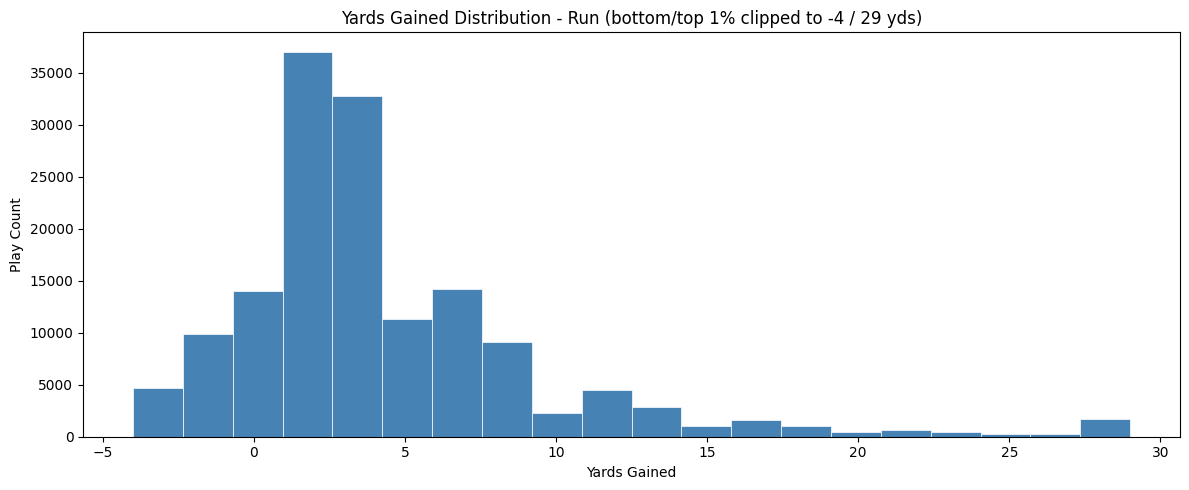

In [89]:
temp = df.copy().loc[df['play_type']=='run'].reset_index(drop=True)

low = temp['yards_gained'].quantile(0.01)
high = temp['yards_gained'].quantile(0.99)

clipped = temp['yards_gained'].dropna().clip(lower=low, upper=high)

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(clipped, bins=20, color='steelblue', edgecolor='white', linewidth=0.5)

ax.set_xlabel('Yards Gained')
ax.set_ylabel('Play Count')
ax.set_title(f'Yards Gained Distribution - Run (bottom/top 1% clipped to {low:.0f} / {high:.0f} yds)')
plt.tight_layout()
plt.show()

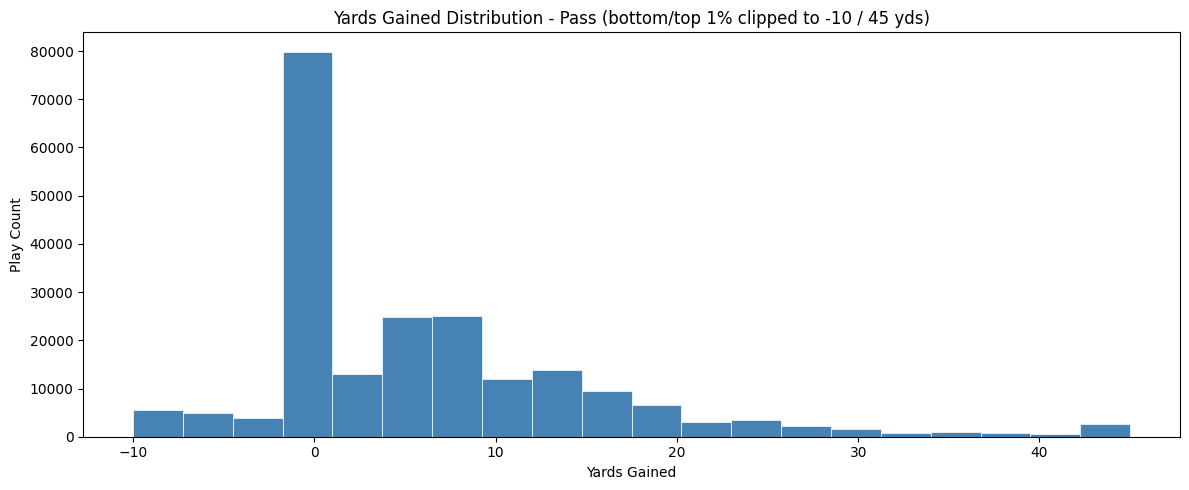

In [90]:
temp = df.copy().loc[df['play_type']=='pass'].reset_index(drop=True)

low = temp['yards_gained'].quantile(0.01)
high = temp['yards_gained'].quantile(0.99)

clipped = temp['yards_gained'].dropna().clip(lower=low, upper=high)

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(clipped, bins=20, color='steelblue', edgecolor='white', linewidth=0.5)

ax.set_xlabel('Yards Gained')
ax.set_ylabel('Play Count')
ax.set_title(f'Yards Gained Distribution - Pass (bottom/top 1% clipped to {low:.0f} / {high:.0f} yds)')
plt.tight_layout()
plt.show()

In [96]:
print("This is the percent of passes that are incomplete: "+str(round(100*sum(df['incomplete_pass'])/sum(df['play_type']=='pass'),2))+"%")

This is the percent of passes that are incomplete: 32.66%


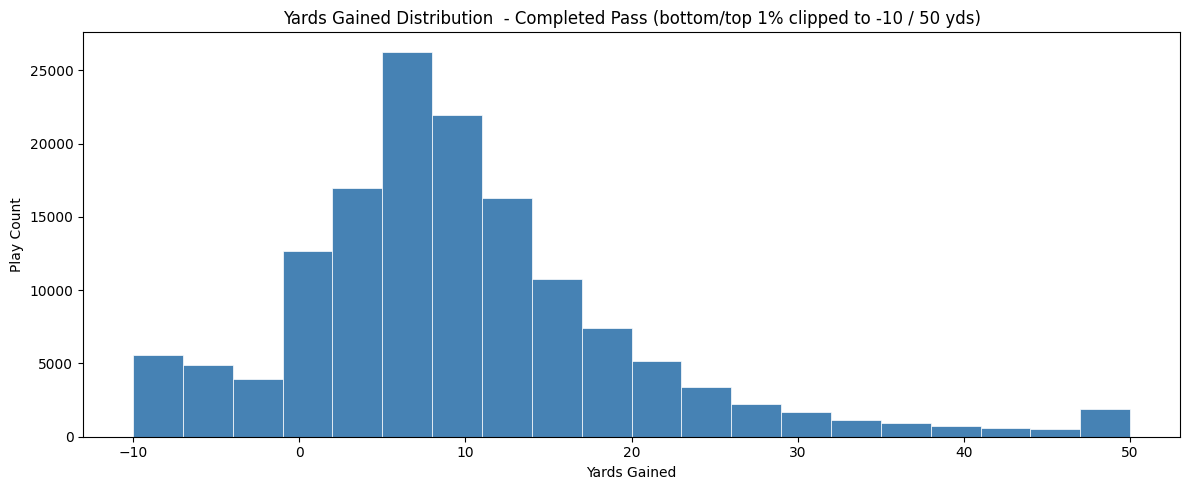

In [91]:
temp = df.copy().loc[(df['play_type']=='pass')&(df['incomplete_pass']==0)].reset_index(drop=True)

low = temp['yards_gained'].quantile(0.01)
high = temp['yards_gained'].quantile(0.99)

clipped = temp['yards_gained'].dropna().clip(lower=low, upper=high)

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(clipped, bins=20, color='steelblue', edgecolor='white', linewidth=0.5)

ax.set_xlabel('Yards Gained')
ax.set_ylabel('Play Count')
ax.set_title(f'Yards Gained Distribution  - Completed Pass (bottom/top 1% clipped to {low:.0f} / {high:.0f} yds)')
plt.tight_layout()
plt.show()

## Univariate Analysis


Variable: down


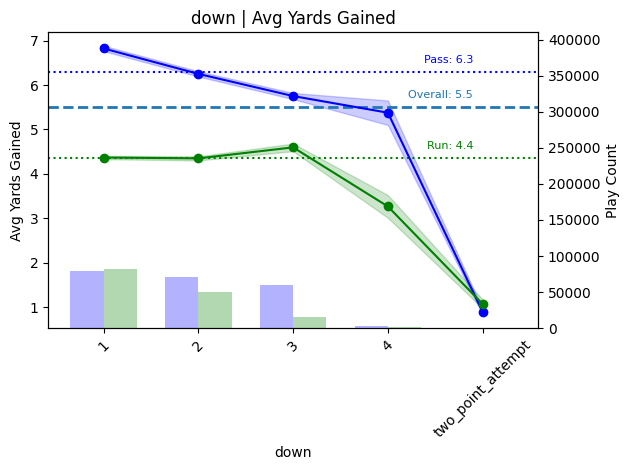


Variable: qtr


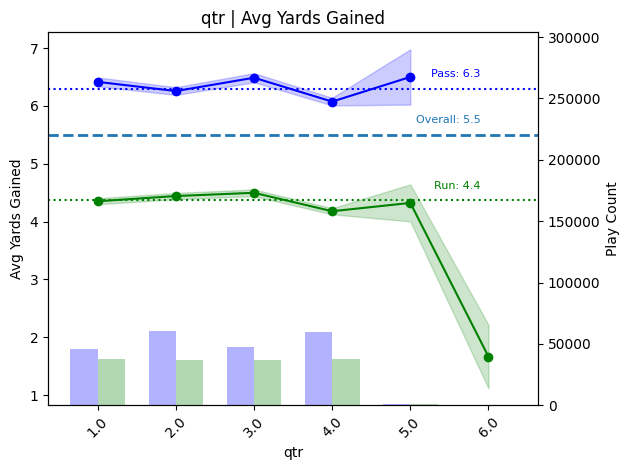


Variable: quarter_seconds_remaining


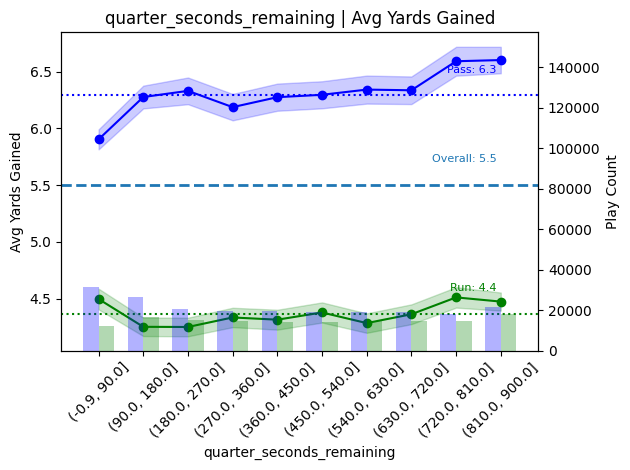


Variable: half_seconds_remaining


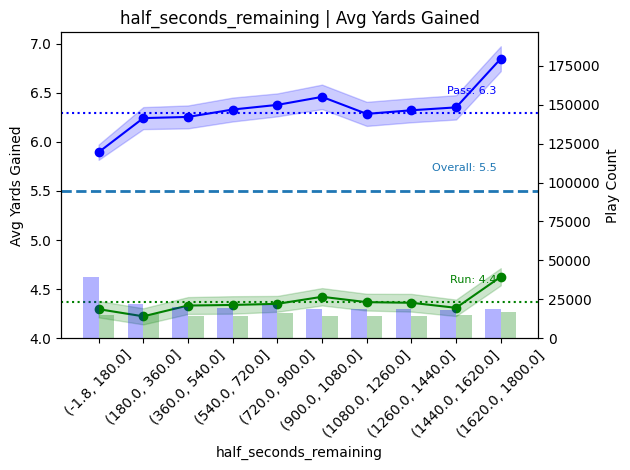


Variable: game_seconds_remaining


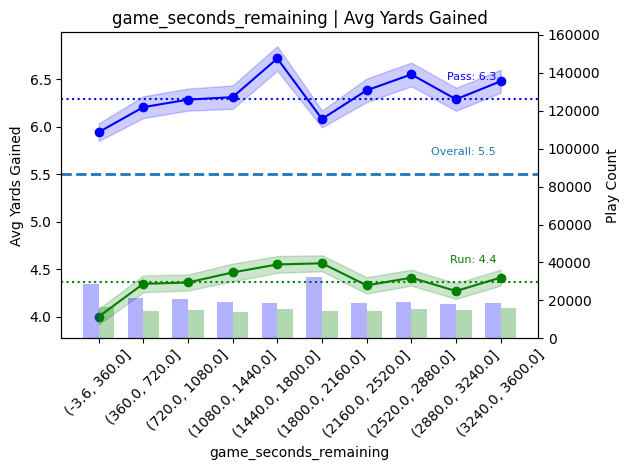


Variable: goal_to_go


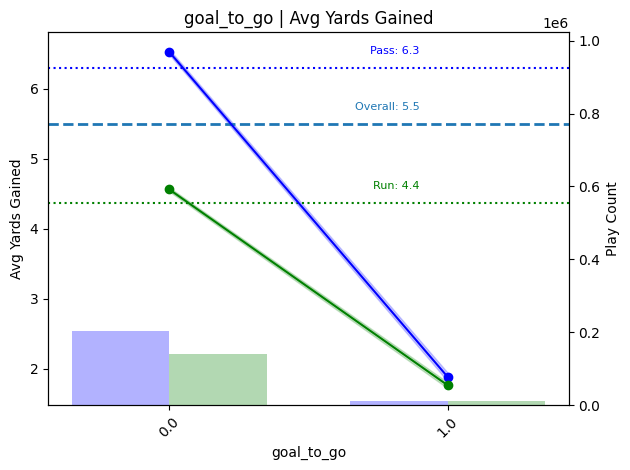


Variable: ydstogo


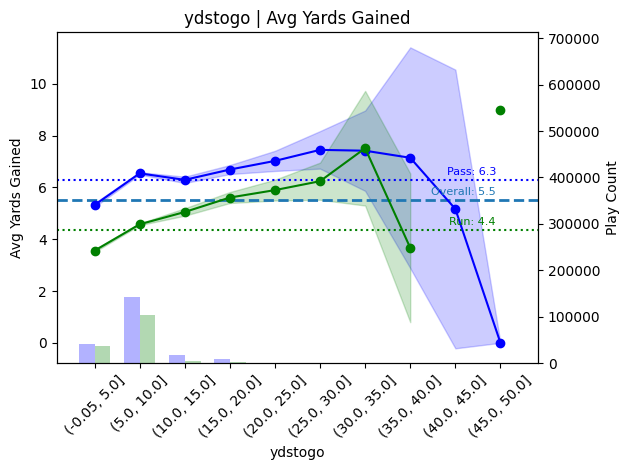


Variable: yards_until_endzone


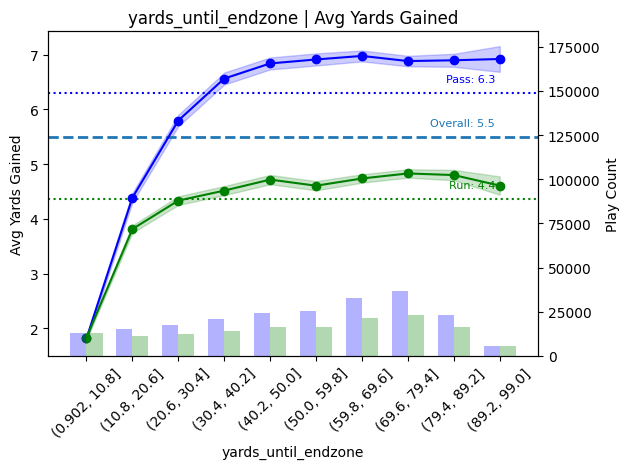


Variable: score_diff


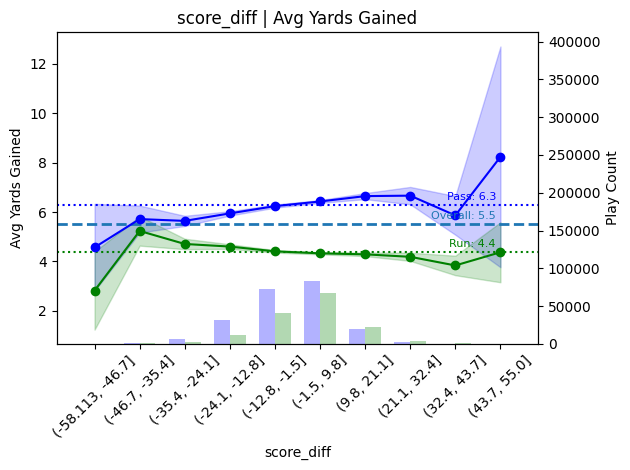


Variable: Season


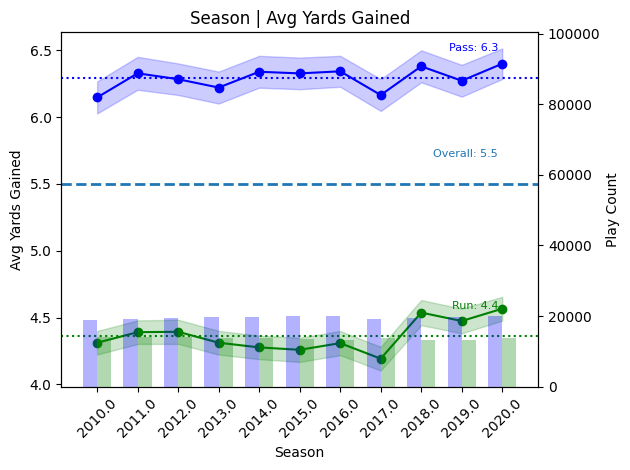


Variable: posteam


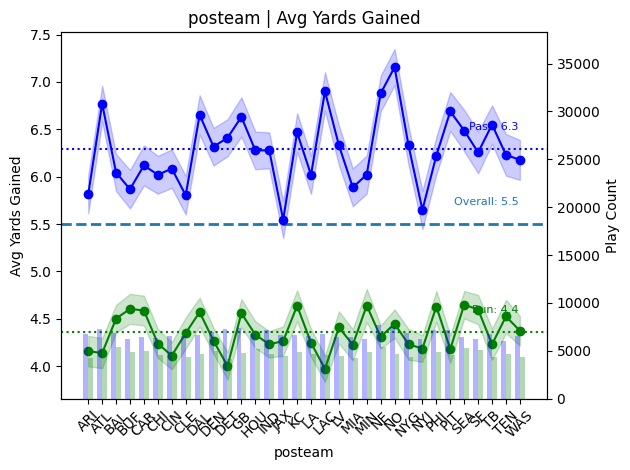


Variable: posteam_type


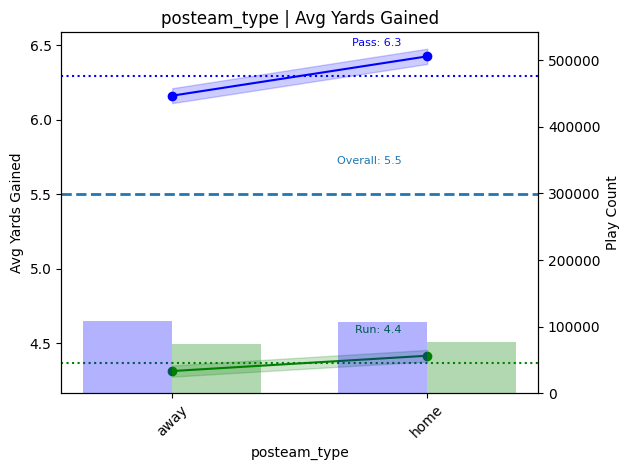


Variable: defteam


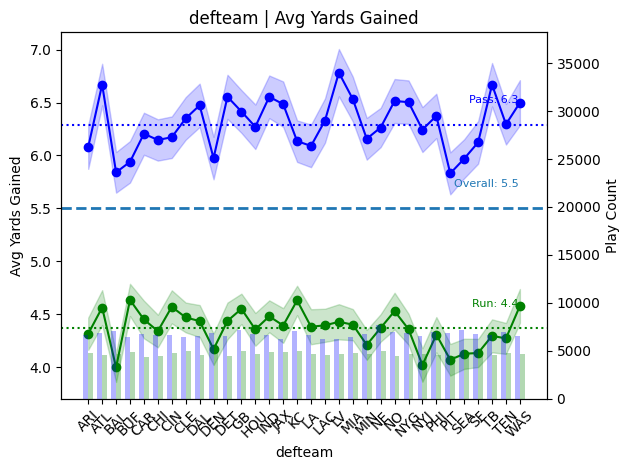


Variable: off_rank


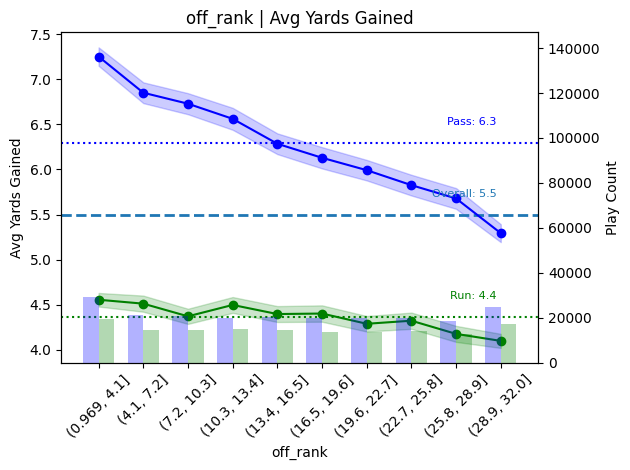


Variable: prev_off_rank


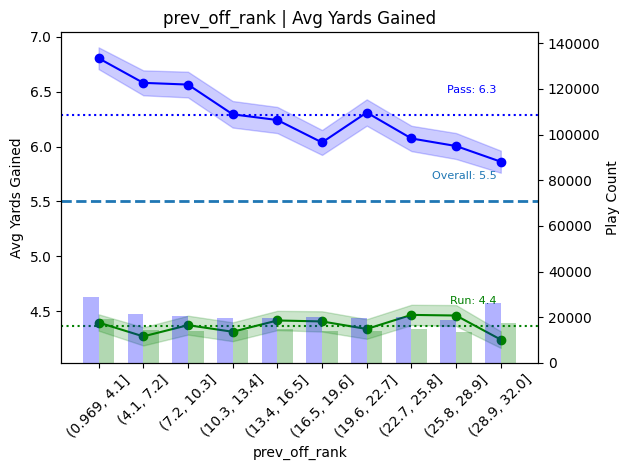


Variable: def_rank


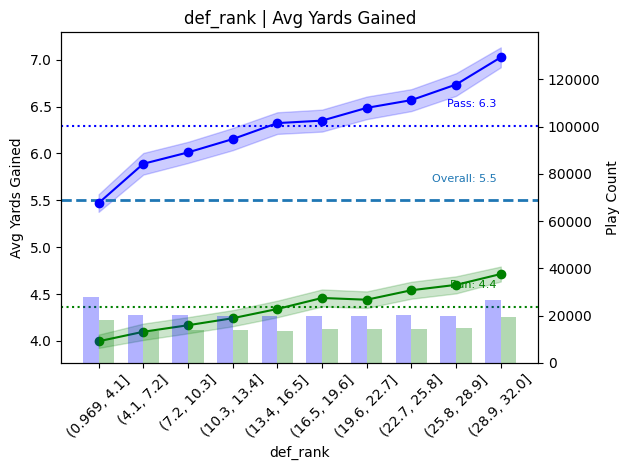


Variable: prev_def_rank


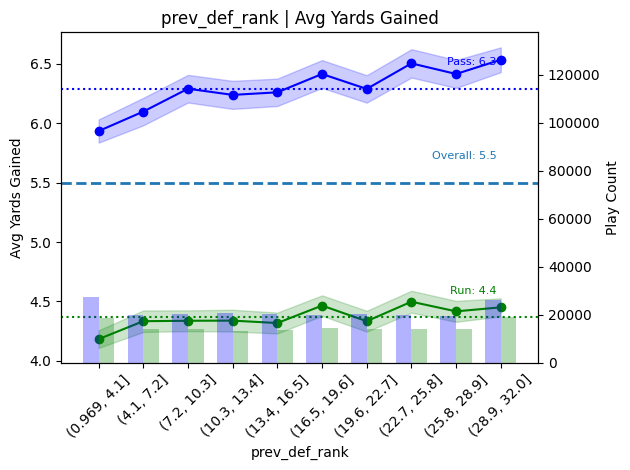


Variable: play_type


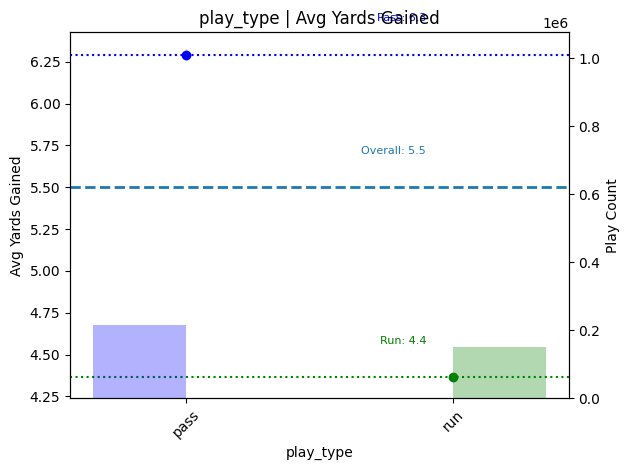


Variable: pass_length


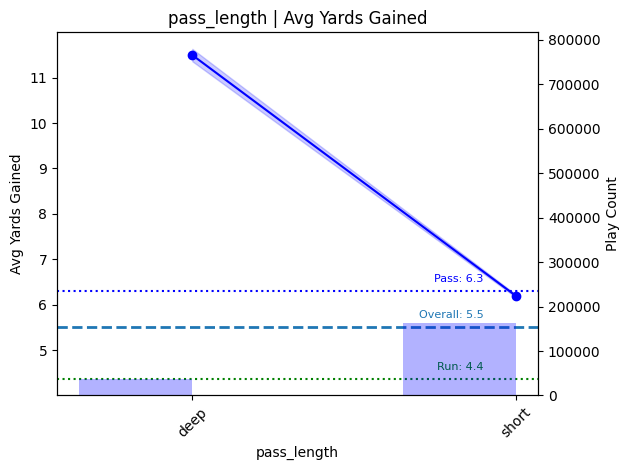


Variable: pass_location


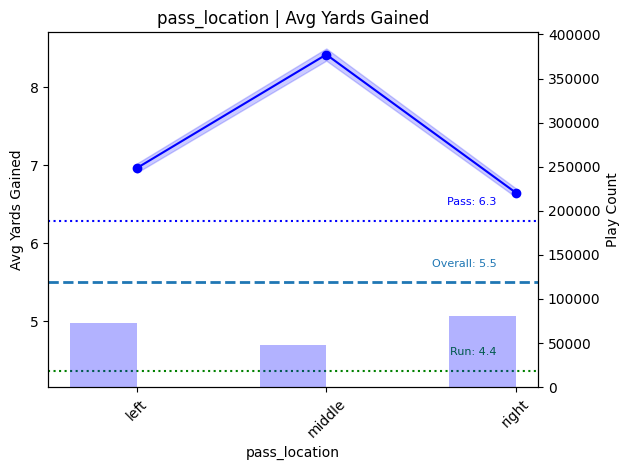


Variable: run_location


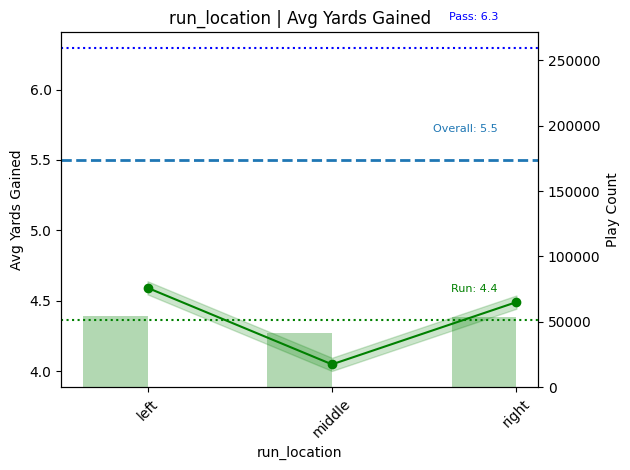


Variable: run_gap


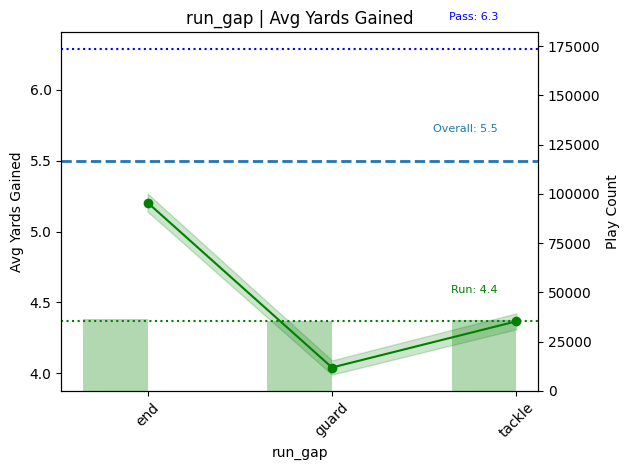


Variable: shotgun


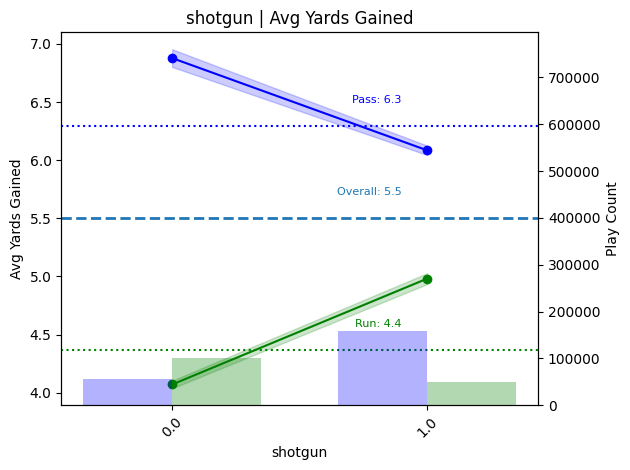


Variable: no_huddle


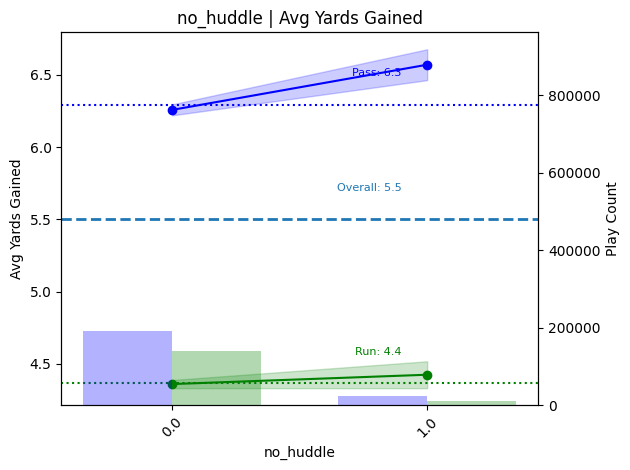


Variable: qb_dropback


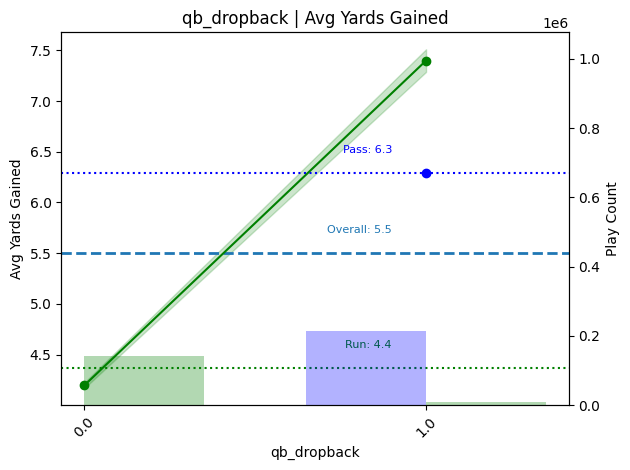


Variable: qb_scramble


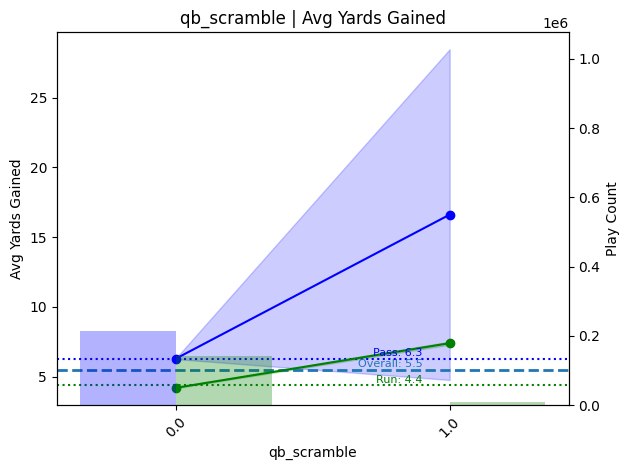

In [49]:
univariate_variables = situation_variables + team_variables + run_vs_pass + other_variables

def is_continuous(series):
    if series.nunique() > 20:
        try:
            series.astype(float)
            return True
        except (ValueError, TypeError):
            return False
    return False
    
for variable in univariate_variables:
    print(f"\nVariable: {variable}")

    pass_data = df[df['play_type'] == 'pass'].copy()
    run_data = df[df['play_type'] == 'run'].copy()

    overall_avg = df['yards_gained'].mean()
    pass_avg = pass_data['yards_gained'].mean()
    run_avg = run_data['yards_gained'].mean()

    play_type_configs = [
        ('pass', pass_data, 'blue'),
        ('run', run_data, 'green')
    ]

    fig, ax1 = plt.subplots()
    ax1.axhline(y=overall_avg, color='#1F77B4', linestyle='--', linewidth=2)
    ax1.axhline(y=pass_avg, color='blue', linestyle=':', linewidth=1.5)
    ax1.axhline(y=run_avg, color='green', linestyle=':', linewidth=1.5)

    all_counts = []
    grouped_by_pt = {}

    full_data = df[[variable, 'yards_gained']].dropna().copy()
    if full_data[variable].nunique() <= 1 or len(full_data) == 0:
        plt.close()
        continue

    continuous = is_continuous(full_data[variable])
    shared_bins = None
    if continuous:
        _, shared_bins = pd.cut(full_data[variable].astype(float), bins=10, retbins=True)

    for play_type, pt_data, color in play_type_configs:
        data = pt_data[[variable, 'yards_gained']].dropna().copy()
        if len(data) == 0:
            continue

        if continuous:
            data[variable] = pd.cut(data[variable].astype(float), bins=shared_bins)

        grouped = data.groupby(variable).agg(
            avg_yards=('yards_gained', 'mean'),
            sigma=('yards_gained', 'std'),
            play_count=('yards_gained', 'count')
        ).reset_index()

        if continuous:
            grouped = grouped.sort_values(variable)
        else:
            try:
                grouped[variable] = grouped[variable].astype(float)
                grouped = grouped.sort_values(variable)
            except (ValueError, TypeError):
                grouped = grouped.sort_values(variable)

        grouped[variable] = grouped[variable].astype(str)
        grouped_by_pt[play_type] = (grouped, color)

    if not grouped_by_pt:
        plt.close()
        continue

    if continuous:
        all_buckets = list(list(grouped_by_pt.values())[0][0][variable])
    else:
        all_buckets = set()
        for play_type, (grouped, color) in grouped_by_pt.items():
            all_buckets.update(grouped[variable].tolist())
        try:
            all_buckets = sorted(all_buckets, key=lambda x: float(x))
        except (ValueError, TypeError):
            all_buckets = sorted(all_buckets)

    x = np.arange(len(all_buckets))
    bucket_idx = {b: i for i, b in enumerate(all_buckets)}
    bar_width = 0.35
    ax2 = ax1.twinx()

    for i, (play_type, (grouped, color)) in enumerate(grouped_by_pt.items()):
        buckets = grouped[variable].tolist()
        xi = np.array([bucket_idx[b] for b in buckets if b in bucket_idx])
        filtered = grouped[grouped[variable].isin(bucket_idx.keys())]
        means = filtered['avg_yards'].values
        sigma = filtered['sigma'].values
        counts = filtered['play_count'].values
        all_counts.extend(counts)

        margin = 1.645 * sigma / np.sqrt(counts)
        lower = means - margin
        upper = means + margin

        offset = (i - 0.5) * bar_width
        ax1.plot(xi, means, marker='o', color=color)
        ax1.fill_between(xi, lower, upper, alpha=0.2, color=color)
        ax2.bar(xi + offset, counts, width=bar_width, alpha=0.3, color=color)

    xmax = len(all_buckets) - 1
    ax1.annotate(f'Overall: {overall_avg:.1f}', xy=(xmax, overall_avg), xytext=(xmax - 0.1, overall_avg + 0.2), color='#1F77B4', fontsize=8, ha='right')
    ax1.annotate(f'Pass: {pass_avg:.1f}', xy=(xmax, pass_avg), xytext=(xmax - 0.1, pass_avg + 0.2), color='blue', fontsize=8, ha='right')
    ax1.annotate(f'Run: {run_avg:.1f}', xy=(xmax, run_avg), xytext=(xmax - 0.1, run_avg + 0.2), color='green', fontsize=8, ha='right')

    ax1.set_xlabel(variable)
    ax1.set_ylabel("Avg Yards Gained")
    ax1.set_xticks(x)
    ax1.set_xticklabels(all_buckets, rotation=45)
    ax2.set_ylabel("Play Count")
    ax2.set_ylim(0, 5 * max(all_counts))

    plt.title(f"{variable} | Avg Yards Gained")
    plt.tight_layout()
    plt.show()

## Correlation Matrices

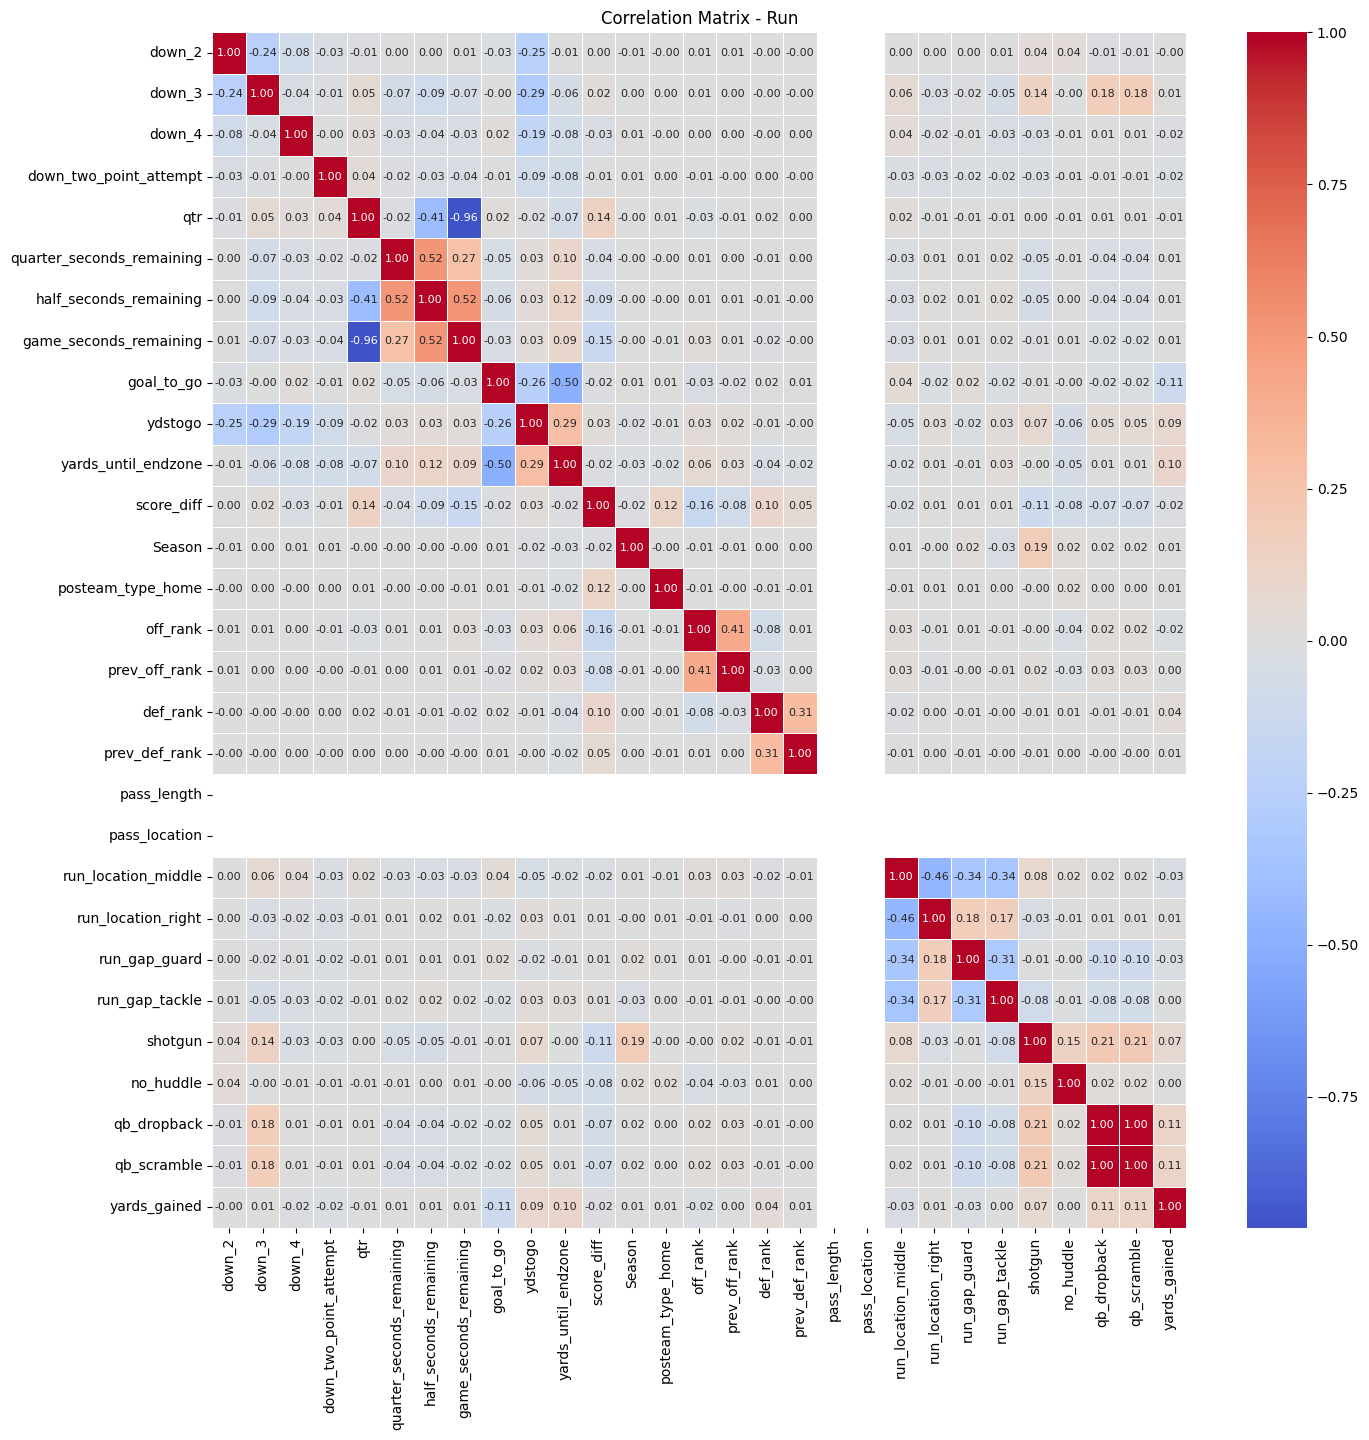

In [60]:
corr_data = df[[c for c in univariate_variables if c not in ['posteam','defteam']] + ['yards_gained']].loc[df['play_type']=='run'].copy()

# one hot encode categoricals, coerce rest to numeric
encoded_frames = []
for col in corr_data.columns:
    try:
        encoded_frames.append(corr_data[[col]].astype(float))
    except (ValueError, TypeError):
        dummies = pd.get_dummies(corr_data[col], prefix=col, drop_first=True)
        encoded_frames.append(dummies)

corr_data_encoded = pd.concat(encoded_frames, axis=1)

corr_matrix = corr_data_encoded.corr()

fig, ax = plt.subplots(figsize=(max(14, len(corr_matrix) * 0.5), max(12, len(corr_matrix) * 0.5)))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': max(6, 10 - len(corr_matrix) // 10)},
    ax=ax
)
plt.title('Correlation Matrix - Run')
plt.tight_layout()
plt.show()

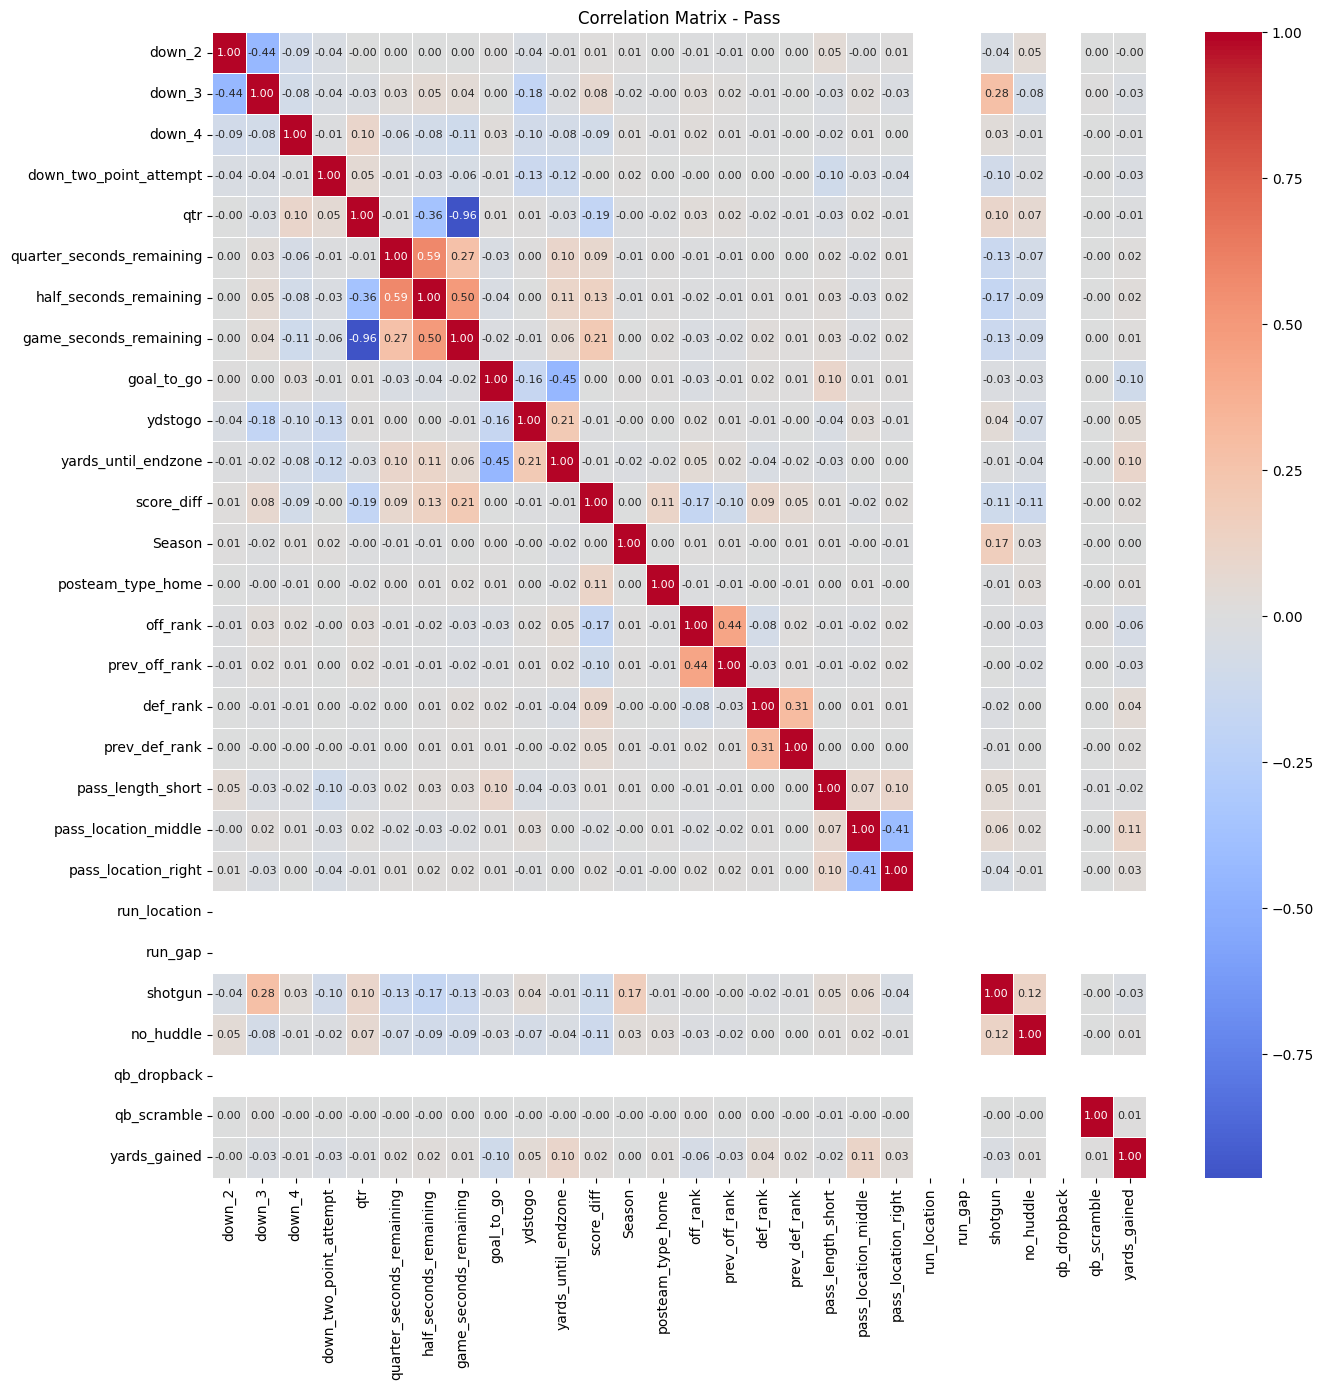

In [61]:
corr_data = df[[c for c in univariate_variables if c not in ['posteam','defteam']] + ['yards_gained']].loc[df['play_type']=='pass'].copy()

# one hot encode categoricals, coerce rest to numeric
encoded_frames = []
for col in corr_data.columns:
    try:
        encoded_frames.append(corr_data[[col]].astype(float))
    except (ValueError, TypeError):
        dummies = pd.get_dummies(corr_data[col], prefix=col, drop_first=True)
        encoded_frames.append(dummies)

corr_data_encoded = pd.concat(encoded_frames, axis=1)

corr_matrix = corr_data_encoded.corr()

fig, ax = plt.subplots(figsize=(max(14, len(corr_matrix) * 0.5), max(12, len(corr_matrix) * 0.5)))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': max(6, 10 - len(corr_matrix) // 10)},
    ax=ax
)
plt.title('Correlation Matrix - Pass')
plt.tight_layout()
plt.show()

## Cateogorical Review

In [67]:
categorical_list = [c for c in univariate_variables if len(set(df[c])) < 10]

for i in range(len(categorical_list)):
    for j in range(i + 1, len(categorical_list)):
        var1 = categorical_list[i]
        var2 = categorical_list[j]

        crosstab_counts = pd.crosstab(df[var1], df[var2], margins=True)
        crosstab_pct = pd.crosstab(df[var1], df[var2], normalize='all').mul(100).round(1)

        print(f"\n{'='*60}")
        print(f"{var1}  x  {var2}")
        print(f"\n--- Counts ---")
        print(crosstab_counts.to_string())
        print(f"\n--- Percentages (% of total) ---")
        print(crosstab_pct.to_string() + '%')


down  x  qtr

--- Counts ---
qtr                    1      2      3      4     5  6     All
down                                                          
1                  37672  43265  38223  41636  1100  1  161897
2                  28097  32615  28036  31912   834  1  121495
3                  17240  20412  16952  20387   504  1   75496
4                    593   1001    839   3203    37  0    5673
two_point_attempt     21     78    173    706     0  0     978
All                83623  97371  84223  97844  2475  3  365539

--- Percentages (% of total) ---
qtr                   1     2     3     4    5    6
down                                               
1                  10.3  11.8  10.5  11.4  0.3  0.0
2                   7.7   8.9   7.7   8.7  0.2  0.0
3                   4.7   5.6   4.6   5.6  0.1  0.0
4                   0.2   0.3   0.2   0.9  0.0  0.0
two_point_attempt   0.0   0.0   0.0   0.2  0.0  0.0%

down  x  goal_to_go

--- Counts ---
goal_to_go              0     

- down x shotgun — Shotgun usage spikes dramatically on 3rd down
- down x play_type — higher pass rate on 3rd down
- down x qb_dropback — corroborates above
- play_type x shotgun — most passes come from shotgun while most runs don't
- shotgun x qb_dropback — more shotgun plays are dropbacks vs under center